<a href="https://colab.research.google.com/github/keirabasma/Formation-IA/blob/main/SEGHIER_Nour_el_houda_Regression_HomeWork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Nom : Seghier
- Prénom : Nour El Houda
- Domaine : Génie des Procédés
- Spécialité : Procédés Organiques

In [14]:
from sklearn.metrics import r2_score

# Prédictions du modèle simple sur tout le dataset
y_pred_simple = model_simple.predict(X_simple)
r2_simple = r2_score(y, y_pred_simple)
print("R² (régression simple) :", r2_simple)

# Prédictions du modèle multiple
y_pred_multiple = model_multiple.predict(X_multiple)
r2_multiple = r2_score(y, y_pred_multiple)
print("R² (régression multiple) :", r2_multiple)


R² (régression simple) : 0.28707700259705604
R² (régression multiple) : 0.6731236206414506


In [12]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Variables explicatives (toutes sauf price et rownames)
X_multiple = df[['lotsize', 'bedrooms', 'bathrms', 'stories',
                 'driveway', 'recroom', 'fullbase', 'gashw',
                 'airco', 'garagepl', 'prefarea']].copy() # Use .copy() to avoid SettingWithCopyWarning

# Convert categorical 'yes'/'no' columns to 1/0
for col in ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']:
    X_multiple[col] = X_multiple[col].map({'yes': 1, 'no': 0})

y = df['price']

model_multiple = LinearRegression()
model_multiple.fit(X_multiple, y)

print("Régression multiple : price ~ toutes les autres variables")
print("Intercept (b0) :", model_multiple.intercept_)
print("Coefficients :")
for col, coef in zip(X_multiple.columns, model_multiple.coef_):
    print(col, ":", coef)

# Exemple de prédiction pour une maison fictive
nouvelle_maison = pd.DataFrame({
    'lotsize': [3000],
    'bedrooms': [3],
    'bathrms': [1],
    'stories': [2],
    'driveway': ['yes'], # Change to 'yes'/'no' for consistency
    'recroom': ['no'],
    'fullbase': ['yes'],
    'gashw': ['no'],
    'airco': ['yes'],
    'garagepl': [1],
    'prefarea': ['no']
})

# Apply the same mapping to the new house data for prediction
for col in ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']:
    nouvelle_maison[col] = nouvelle_maison[col].map({'yes': 1, 'no': 0})

prix_pred_mult = model_multiple.predict(nouvelle_maison)
print("Prix prédit (régression multiple) :", prix_pred_mult[0])

Régression multiple : price ~ toutes les autres variables
Intercept (b0) : -4038.3504250983824
Coefficients :
lotsize : 3.5463029700849362
bedrooms : 1832.0034656485477
bathrms : 14335.558468345615
stories : 6556.94571149102
driveway : 6687.778890416117
recroom : 4511.283826105556
fullbase : 5452.385539447686
gashw : 12831.406266411801
airco : 12632.89040481588
garagepl : 4244.829004332623
prefarea : 9369.513238928876
Prix prédit (régression multiple) : 68563.90261244203


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


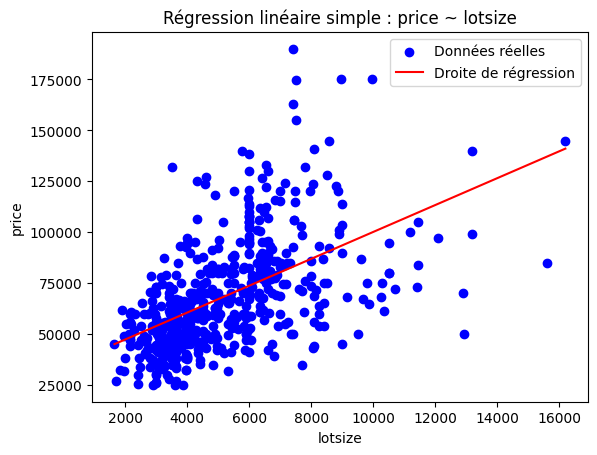

In [10]:
import matplotlib.pyplot as plt

# Nuage de points
plt.scatter(df['lotsize'], df['price'], color='blue', label='Données réelles')

# Droite de régression
X_plot = np.linspace(df['lotsize'].min(), df['lotsize'].max(), 100).reshape(-1, 1)
y_plot = model_simple.predict(X_plot)

plt.plot(X_plot, y_plot, color='red', label='Droite de régression')

plt.xlabel('lotsize')
plt.ylabel('price')
plt.title('Régression linéaire simple : price ~ lotsize')
plt.legend()
plt.show()


In [9]:
# 4) Régression linéaire simple : Y = price, X = lotsize

# Variable explicative (X) doit être en 2D => [[x1],[x2],...]
X_simple = df[['lotsize']]   # double crochets => DataFrame 2D
y = df['price']              # variable cible

# Créer le modèle
model_simple = LinearRegression()

# Entraîner (ajuster) le modèle
model_simple.fit(X_simple, y)

# Afficher les coefficients
print("Intercept (b0) :", model_simple.intercept_)
print("Pente (b1) pour lotsize :", model_simple.coef_[0])

# Exemple : prédire le prix pour une taille de terrain donnée
taille_exemple = np.array([[3000]])  # par exemple lotsize=3000
prix_pred = model_simple.predict(taille_exemple)
print("Prix prédit pour lotsize = 3000 :", prix_pred[0])


Intercept (b0) : 34136.191564915054
Pente (b1) pour lotsize : 6.5987675892656
Prix prédit pour lotsize = 3000 : 53932.49433271185


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [6]:
# Afficher les 5 premières lignes
print(df.head())

# Informations générales (types, valeurs manquantes, etc.)
print(df.info())

# Quelques statistiques descriptives
print(df.describe())


   rownames  price  lotsize  bedrooms  bathrms  stories driveway recroom  \
0         1  42000     5850         3        1        2      yes      no   
1         2  38500     4000         2        1        1      yes      no   
2         3  49500     3060         3        1        1      yes      no   
3         4  60500     6650         3        1        2      yes     yes   
4         5  61000     6360         2        1        1      yes      no   

  fullbase gashw airco  garagepl prefarea  
0      yes    no    no         1       no  
1       no    no    no         0       no  
2       no    no    no         0       no  
3       no    no    no         0       no  
4       no    no    no         0       no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  546 non-null    int64 
 1   price     546 non-null    int64 
 2   lotsize   546 non

In [5]:
# 3) Lire le CSV dans un DataFrame pandas
df = pd.read_csv('homework.csv')  # mets ici le nom exact de ton fichier


In [4]:
from google.colab import files

# 2) Importer le fichier depuis votre ordinateur
uploaded = files.upload()   # ceci va ouvrir une fenêtre pour choisir le fichier .csv


Saving homework.csv to homework (1).csv


In [2]:
# 1) Importer les bibliothèques principales
import pandas as pd
import numpy as np

# Pour tracer des graphiques (optionnel mais utile)
import matplotlib.pyplot as plt

# Pour la régression linéaire
from sklearn.linear_model import LinearRegression
